In [ ]:
import pandas as pd 
import numpy as np 


df = pd.read_csv("/Users/nakul/Desktop/PHYS/Equity-Signal-/data/ratio_with_returns.csv")
df["snapshot"] = pd.to_datetime(df["snapshot"])

print("Shape:", df.shape)
print("\nYears available:", sorted(df["snapshot"].dt.year.unique()))

years = sorted(df["snapshot"].dt.year.unique())
n_years = len(years)

n_train = int(n_years * 0.70)
n_val = int(n_years * 0.15)
#train_years = years[:n_train]
#val_years = years[n_train:n_train + n_val]
#test_years = years[n_train + n_val:]

train_years = [y for y in years if y <= 2020]
val_years = [y for y in years if y in (2021, 2022)]
test_years = [y for y in years if y >= 2023]


print(f"\nTrain years: {train_years}")
print(f"Val years:   {val_years}")
print(f"Test years:  {test_years}")

train_df = df[df["snapshot"].dt.year.isin(train_years)].copy()
val_df = df[df["snapshot"].dt.year.isin(val_years)].copy()
test_df = df[df["snapshot"].dt.year.isin(test_years)].copy()

print(f"\nTrain rows: {len(train_df)} ({len(train_df)/len(df)*100:.1f}%)")
print(f"Val rows:   {len(val_df)} ({len(val_df)/len(df)*100:.1f}%)")
print(f"Test rows:  {len(test_df)} ({len(test_df)/len(df)*100:.1f}%)")

feature_cols = ["ROE", "ROA", "GrossMargin", "DebtToEquity", "AssetTurnover", "EPS"]
target_col = "excess_return"

X_train = train_df[feature_cols].values
y_train = train_df[target_col].values

X_val = val_df[feature_cols].values
y_val = val_df[target_col].values

X_test = test_df[feature_cols].values
y_test = test_df[target_col].values

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")



In [11]:
feature_cols = ["ROE", "ROA", "GrossMargin", "DebtToEquity", "AssetTurnover", "EPS"]
target_col = "excess_return"

print("Before dropping NaNs:")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

train_df = train_df.dropna(subset=feature_cols + [target_col]).copy()
val_df = val_df.dropna(subset=feature_cols + [target_col]).copy()
test_df = test_df.dropna(subset=feature_cols + [target_col]).copy()

print("\nAfter dropping NaNs (all feature columns):")
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

X_train = train_df[feature_cols].values
y_train = train_df[target_col].values

X_val = val_df[feature_cols].values
y_val = val_df[target_col].values

X_test = test_df[feature_cols].values
y_test = test_df[target_col].values

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}, y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}, y_test shape:  {y_test.shape}")

print(f"\nAny NaNs left in X_train? {np.isnan(X_train).any()}")
print(f"Any NaNs left in X_val?   {np.isnan(X_val).any()}")
print(f"Any NaNs left in X_test?  {np.isnan(X_test).any()}")

Before dropping NaNs:
Train: 9440, Val: 2829, Test: 4837

After dropping NaNs (all feature columns):
Train: 9257, Val: 2792, Test: 4797

X_train shape: (9257, 6), y_train shape: (9257,)
X_val shape:   (2792, 6), y_val shape:   (2792,)
X_test shape:  (4797, 6), y_test shape:  (4797,)

Any NaNs left in X_train? False
Any NaNs left in X_val?   False
Any NaNs left in X_test?  False


In [26]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_val_scaled = (X_val - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

def add_intercept(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_intercept(X_train_scaled)
X_val_b = add_intercept(X_val_scaled)
X_test_b = add_intercept(X_test_scaled)


def compute_mse(X, y, theta):
    predicitions = X @ theta 
    errors = predicitions - y 
    return np.mean(errors **2)

def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000):
    n_samples, n_features = X.shape
    theta = np.zeros(n_features)
    loss_history = []

    for i in range(n_iterations):
        predictions = X @ theta
        errors = predictions - y
        gradient = (2 / n_samples) * (X.T @ errors)
        theta = theta - learning_rate * gradient

        loss = np.mean(errors ** 2)
        loss_history.append(loss)

    return theta, loss_history

theta, loss_history = gradient_descent(X_train_b, y_train, learning_rate=0.01, n_iterations=500)

print("\nFinal training MSE:", loss_history[-1])
print("Initial training MSE:", loss_history[0])

print("\nLearned parameters (theta):")
feature_names = ["intercept"] + feature_cols
for name, val in zip(feature_names, theta):
    print(f"  {name}: {val:.6f}")

val_mse = compute_mse(X_val_b, y_val, theta)
print(f"\nValidation MSE: {val_mse:.6f}")   



Final training MSE: 0.22042823081928542
Initial training MSE: 0.22290546864178695

Learned parameters (theta):
  intercept: 0.023003
  ROE: 0.002878
  ROA: 0.012842
  GrossMargin: 0.034210
  DebtToEquity: 0.010750
  AssetTurnover: 0.027066
  EPS: -0.024009

Validation MSE: 0.209282


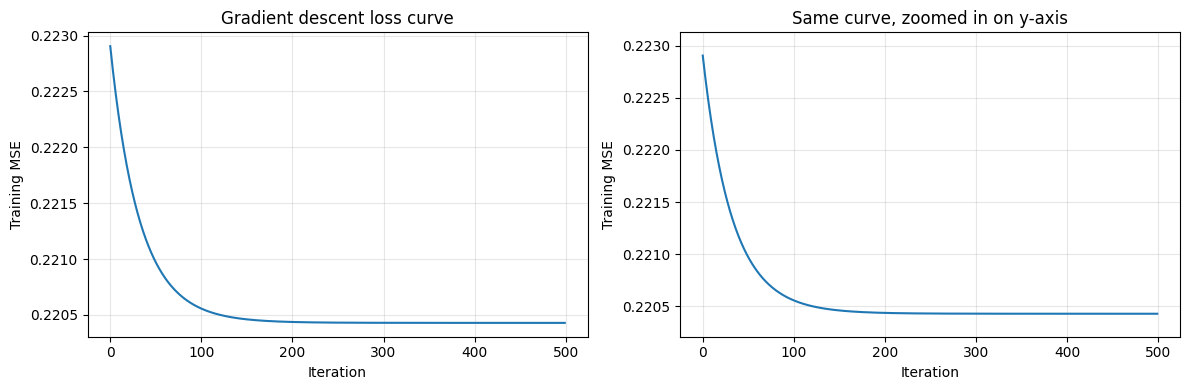

Initial loss: 0.222905
Final loss:   0.220428
Total reduction: 0.002477 (1.11%)


In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: full loss curve, linear scale
axes[0].plot(loss_history)
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Training MSE")
axes[0].set_title("Gradient descent loss curve")
axes[0].grid(True, alpha=0.3)

# Right: same curve but zoomed in on the y-axis to make the small movement visible
axes[1].plot(loss_history)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Training MSE")
axes[1].set_title("Same curve, zoomed in on y-axis")
axes[1].set_ylim(min(loss_history) * 0.999, max(loss_history) * 1.001)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Initial loss: {loss_history[0]:.6f}")
print(f"Final loss:   {loss_history[-1]:.6f}")
print(f"Total reduction: {(loss_history[0] - loss_history[-1]):.6f} "
      f"({(1 - loss_history[-1]/loss_history[0])*100:.2f}%)")